# 5.3 Evaluation

This notebook performs the final evaluation of all three trained models against the NSL-KDD test set.

**Contents:**
1. Load preprocessed data (OHE for KNN/SVM, LE for Naive Bayes)
2. Retrain all three models
3. Per-model classification reports
4. ROC curves + AUC
5. Precision-Recall curves + Average Precision
6. Stability analysis
7. Radar chart
8. Final comparison table
9. Interpretation

In [9]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from src.train import train_knn, train_nb, train_svm, stability_analysis
from src.evaluate import (
    metrics_summary,
    plot_roc,
    plot_pr,
    final_comparison_table,
    print_classification_reports,
    plot_radar,
    interpret_results,
)

sns.set_theme(style="whitegrid", palette="muted")
REPORT_DIR = "../reports"
os.makedirs(REPORT_DIR, exist_ok=True)
print('Imports OK')

Imports OK


## Step 1 — Load Data

Load both encoded versions from `data/processed/` — saved by notebook 5.1.
- OHE (122 features) → KNN and SVM
- LE (41 features) → Naive Bayes

In [10]:
# OHE — KNN and SVM
X_train_ohe = pd.read_csv("../data/processed/X_train_ohe.csv")
X_test_ohe  = pd.read_csv("../data/processed/X_test_ohe.csv")

# LE — Naive Bayes
X_train_le  = pd.read_csv("../data/processed/X_train_le.csv")
X_test_le   = pd.read_csv("../data/processed/X_test_le.csv")

# Labels (shared)
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"OHE — X_train: {X_train_ohe.shape}  X_test: {X_test_ohe.shape}")
print(f"LE  — X_train: {X_train_le.shape}   X_test: {X_test_le.shape}")
print(f"y_train: {y_train.value_counts().to_dict()}")
print(f"y_test : {y_test.value_counts().to_dict()}")

OHE — X_train: (125973, 122)  X_test: (22543, 122)
LE  — X_train: (125973, 41)   X_test: (22543, 41)
y_train: {0: 67343, 1: 58630}
y_test : {1: 12833, 0: 9710}


## Step 2 — Retrain Models

We retrain using the same best hyperparameters found in notebook 5.2.


In [11]:
# KNN — OHE
knn_model, knn_metrics, knn_cv_scores, best_k = train_knn(
    X_train_ohe, y_train, X_test_ohe, y_test,
    k_range=range(1, 22, 2)
)

# Naive Bayes — LE
nb_model, nb_metrics = train_nb(X_train_le, y_train, X_test_le, y_test)

# SVM — OHE, with threshold tuning
svm_model, svm_metrics, svm_best_params, svm_sample, best_threshold, threshold_df = train_svm(
    X_train_ohe, y_train, X_test_ohe, y_test,
    sample_size=25000, cv=3
)

print(f"\nBest K (KNN)       : {best_k}")
print(f"Best SVM params    : {svm_best_params}")
print(f"Best SVM threshold : {best_threshold}")

[tune_knn] Testing K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21] with 5-fold CV...
  K= 1  F1=0.9970 ± 0.0004
  K= 3  F1=0.9962 ± 0.0002
  K= 5  F1=0.9956 ± 0.0003
  K= 7  F1=0.9950 ± 0.0003
  K= 9  F1=0.9943 ± 0.0003
  K=11  F1=0.9939 ± 0.0006
  K=13  F1=0.9938 ± 0.0007
  K=15  F1=0.9934 ± 0.0006
  K=17  F1=0.9932 ± 0.0008
  K=19  F1=0.9931 ± 0.0007
  K=21  F1=0.9928 ± 0.0007

[tune_knn] Best K = 1  (F1 = 0.9970)
[train_knn] NOTE: K=1 selected. CV F1 will appear near-perfect because each training point is its own neighbour. Expect a larger train/test gap — document this as a limitation.

[train_knn] Fitting KNN with K=1...
[train_knn] Test results -> Acc: 0.7792  P: 0.9258  R: 0.6655  F1: 0.7744
[train_nb] Fitting Gaussian Naive Bayes...
[train_nb] Test results → Acc: 0.7709  P: 0.9161  R: 0.6578  F1: 0.7657
[train_svm] Sample size: 25,000  (Normal: 13,365  Attack: 11,635)
[train_svm] Running GridSearchCV (3-fold)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[train_svm

## Step 3 — Classification Reports

Detailed per-class breakdown showing precision, recall, and F1 for both Normal and Attack classes separately.

In [12]:
predictions = {
    "KNN":         knn_metrics["y_pred"],
    "Naive Bayes": nb_metrics["y_pred"],
    "SVM":         svm_metrics["y_pred"],
}

print_classification_reports(y_test, predictions)


  KNN
              precision    recall  f1-score   support

  Normal (0)       0.68      0.93      0.78      9710
  Attack (1)       0.93      0.67      0.77     12833

    accuracy                           0.78     22543
   macro avg       0.80      0.80      0.78     22543
weighted avg       0.82      0.78      0.78     22543


  Naive Bayes
              precision    recall  f1-score   support

  Normal (0)       0.67      0.92      0.78      9710
  Attack (1)       0.92      0.66      0.77     12833

    accuracy                           0.77     22543
   macro avg       0.79      0.79      0.77     22543
weighted avg       0.81      0.77      0.77     22543


  SVM
              precision    recall  f1-score   support

  Normal (0)       0.72      0.91      0.81      9710
  Attack (1)       0.92      0.74      0.82     12833

    accuracy                           0.81     22543
   macro avg       0.82      0.82      0.81     22543
weighted avg       0.83      0.81      0.81  

## Step 4 — ROC Curves

ROC curves plot True Positive Rate vs False Positive Rate at every threshold. AUC = 1.0 is perfect, 0.5 is random.

SVM is trained with `probability=True` so `predict_proba()` is available for all three models.

[plot_roc] Saved → ../reports/roc_curves.png


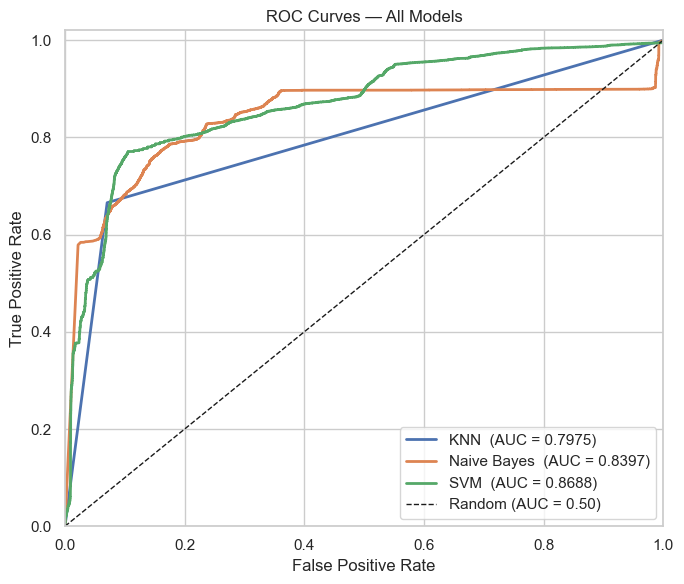


AUC Scores:
  KNN            : 0.7975
  Naive Bayes    : 0.8397
  SVM            : 0.8688


In [13]:
proba_dict = {
    "KNN":         knn_model.predict_proba(X_test_ohe)[:, 1],
    "Naive Bayes": nb_model.predict_proba(X_test_le)[:, 1],
    "SVM":         svm_model.predict_proba(X_test_ohe)[:, 1],
}

auc_scores = plot_roc(
    y_test, proba_dict,
    save_path=f"{REPORT_DIR}/roc_curves.png"
)

print("\nAUC Scores:")
for name, score in auc_scores.items():
    print(f"  {name:15s}: {score:.4f}")

## Step 5 — Precision-Recall Curves

PR curves are particularly relevant for intrusion detection because:
- **Recall** (y-axis at threshold=0.5) = fraction of actual attacks detected → our priority metric
- **Precision** = fraction of flagged connections that are truly attacks → false alarm rate

A model can achieve high Recall by flagging everything, but precision collapses. A good NIDS needs both to be high. **Average Precision (AP)** summarises the area under the PR curve.

[plot_pr] Saved → ../reports/pr_curves.png


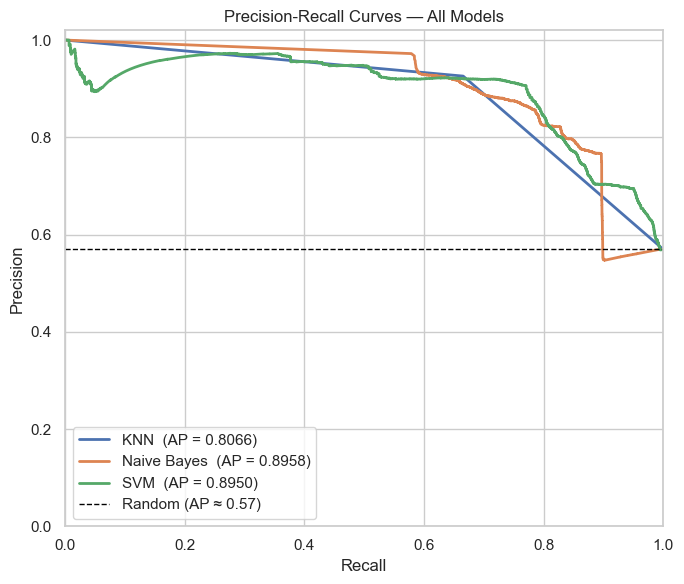


Average Precision Scores:
  KNN            : 0.8066
  Naive Bayes    : 0.8958
  SVM            : 0.8950


In [14]:
ap_scores = plot_pr(
    y_test, proba_dict,
    save_path=f"{REPORT_DIR}/pr_curves.png"
)

print("\nAverage Precision Scores:")
for name, score in ap_scores.items():
    print(f"  {name:15s}: {score:.4f}")

## Step 6 — Stability Analysis

Repeated Stratified K-Fold (10×5 = 50 evaluations per model) measures how consistent each model's F1 is across different data splits.

**CV% (Coefficient of Variation)** = std / mean × 100
- CV% < 2% → very stable
- CV% 2–5% → acceptable
- CV% > 5% → unstable

In [15]:
# KNN + SVM on OHE
stability_ohe, raw_ohe = stability_analysis(
    {
        "KNN": KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
        "SVM": SVC(kernel="rbf", C=svm_best_params["C"],
                   gamma=svm_best_params["gamma"],
                   class_weight="balanced", random_state=42),
    },
    X_train_ohe, y_train,
    n_splits=5, n_repeats=10, scoring="f1", svm_sample_size=25000
)

# Naive Bayes on LE
stability_le, raw_le = stability_analysis(
    {"Naive Bayes": GaussianNB()},
    X_train_le, y_train,
    n_splits=5, n_repeats=10, scoring="f1"
)

stability_df = pd.concat([stability_ohe, stability_le], ignore_index=True)
raw_scores   = {**raw_ohe, **raw_le}

print("\nStability Summary:")
print(stability_df.set_index("Model").to_string())

[stability] Running 10×5-fold CV for KNN...
  → Mean=0.9970  Std=0.0003  CV%=0.03%
[stability] Running 10×5-fold CV for SVM...
  → Mean=0.9863  Std=0.0015  CV%=0.16%
[stability] Running 10×5-fold CV for Naive Bayes...
  → Mean=0.8888  Std=0.0042  CV%=0.47%

Stability Summary:
             Mean F1     Std     Min     Max   CV%  n_evals
Model                                                      
KNN           0.9970  0.0003  0.9962  0.9979  0.03       50
SVM           0.9863  0.0015  0.9824  0.9897  0.16       50
Naive Bayes   0.8888  0.0042  0.8790  0.8953  0.47       50


## Step 7 — Radar Chart

[plot_radar] Saved → ../reports/radar_chart.png


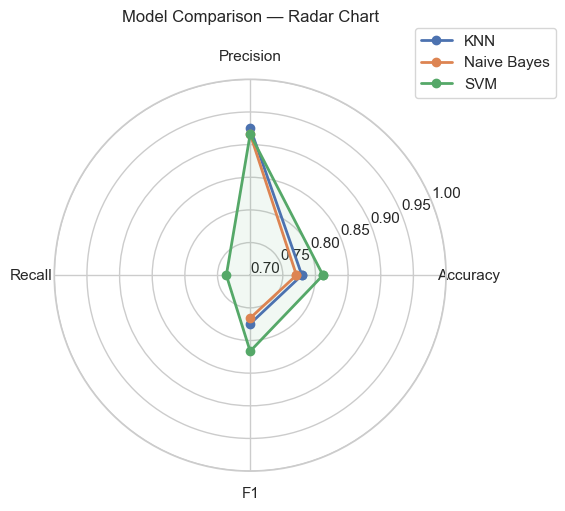

In [17]:
metrics_df = metrics_summary(y_test, predictions)

plot_radar(
    metrics_df,
    save_path=f"{REPORT_DIR}/radar_chart.png"
)

## Step 8 — Final Comparison Table

In [18]:
table = final_comparison_table(
    metrics_df, stability_df, auc_scores, ap_scores
)

print("Final Comparison Table:")
print(table.round(4).to_string())

table.round(4).to_csv(f"{REPORT_DIR}/final_comparison_table.csv")
print(f"\nSaved -> {REPORT_DIR}/final_comparison_table.csv")

Final Comparison Table:
             Accuracy  Precision  Recall      F1     AUC  Avg Precision  CV Mean F1  CV Std   CV%
Model                                                                                            
KNN            0.7792     0.9258  0.6655  0.7744  0.7975         0.8066      0.9970  0.0003  0.03
Naive Bayes    0.7709     0.9161  0.6578  0.7657  0.8397         0.8958      0.8888  0.0042  0.47
SVM            0.8115     0.9160  0.7365  0.8165  0.8688         0.8950      0.9863  0.0015  0.16

Saved -> ../reports/final_comparison_table.csv


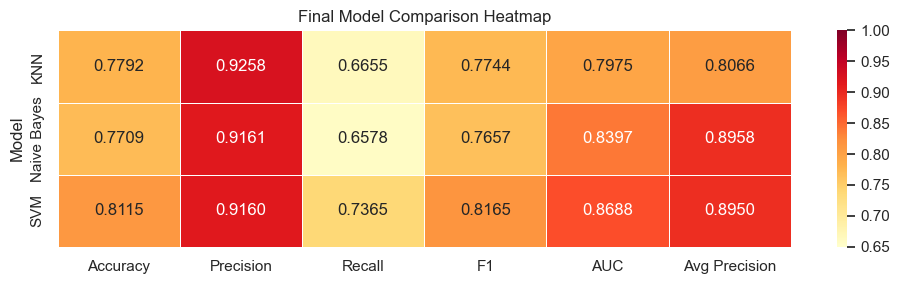

In [19]:
plot_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC", "Avg Precision"]

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    table[plot_cols].astype(float),
    annot=True, fmt=".4f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    vmin=0.65, vmax=1.0
)
ax.set_title("Final Model Comparison Heatmap")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/final_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Interpretation

In [20]:
interpret_results(table)


  INTERPRETATION
  Highest F1       : SVM  (0.8165)
  Highest Recall   : SVM  (0.7365)
  Most Stable      : KNN  (CV% = 0.03%)
  Highest AUC      : SVM  (0.8688)

  NIDS priority metric is Recall (minimise missed attacks).
  → Recommended model: SVM


---
## Summary of All Outputs

In [21]:
all_reports = [
    "feature_groups.png",
    "class_balance.png",
    "scaling_example.png",
    "knn_k_selection.png",
    "svm_threshold_tuning.png",
    "model_comparison.png",
    "confusion_matrices.png",
    "stability_boxplot.png",
    "learning_curves.png",
    "roc_curves.png",
    "pr_curves.png",
    "radar_chart.png",
    "final_heatmap.png",
    "final_comparison_table.csv",
]

print("=" * 50)
print("  PROJECT COMPLETE — All outputs in reports/")
print("=" * 50)
for f in all_reports:
    path = f"{REPORT_DIR}/{f}"
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  {status:7s}  {f}")
print("=" * 50)

  PROJECT COMPLETE — All outputs in reports/
  OK       feature_groups.png
  OK       class_balance.png
  OK       scaling_example.png
  OK       knn_k_selection.png
  OK       svm_threshold_tuning.png
  OK       model_comparison.png
  OK       confusion_matrices.png
  OK       stability_boxplot.png
  OK       learning_curves.png
  OK       roc_curves.png
  OK       pr_curves.png
  OK       radar_chart.png
  OK       final_heatmap.png
  OK       final_comparison_table.csv
